
✨ Informacoes sobre a variável 'EVOLUCAO':

'EVOLUCAO' indica o desfecho clínico do paciente:
1 - Cura
2 - Óbito
3 - Óbito por outras causas
9 - Ignorado
Neste estudo, usamos apenas 1 (Cura) e 2 (Óbito), mapeados para:
0 = Cura, 1 = Óbito


Distribuição antes do balanceamento:
EVOLUCAO
0    50301
1     9533
Name: count, dtype: int64

Distribuição após balanceamento:
EVOLUCAO
1    50301
0    50301
Name: count, dtype: int64

--- Avaliação do Modelo CART (Decision Tree) ---
              precision    recall  f1-score   support

           0       0.79      0.73      0.76     15091
           1       0.75      0.81      0.78     15090

    accuracy                           0.77     30181
   macro avg       0.77      0.77      0.77     30181
weighted avg       0.77      0.77      0.77     30181



/tmp/ipykernel_313889/833497276.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variavel', data=importancias, palette='viridis')


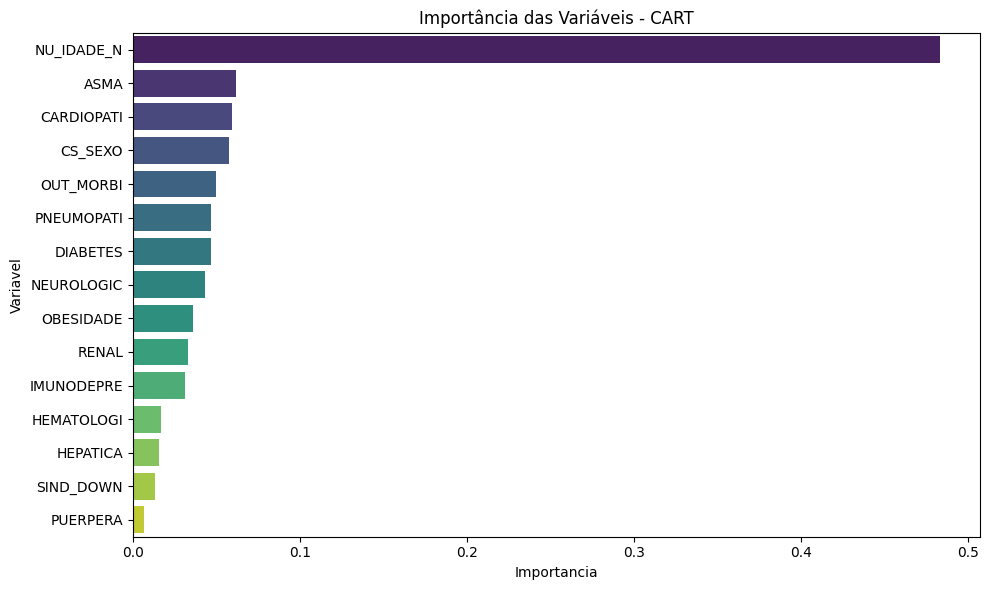

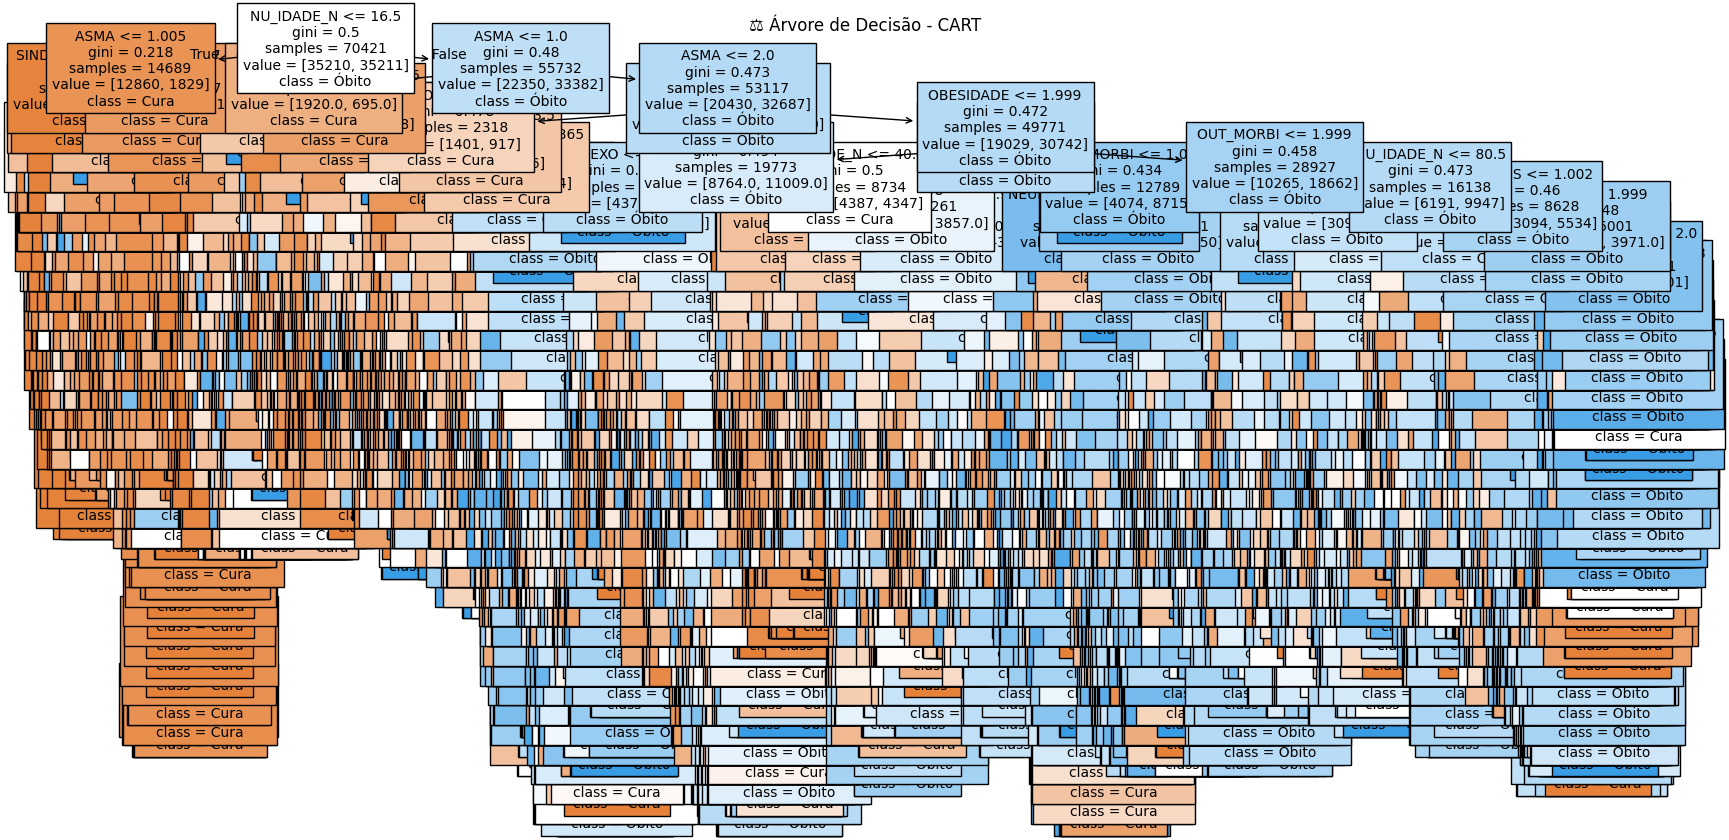


⏱️ Tempo total de execução: 0:02:30.463937


In [1]:
# ✅ Código adaptado para análise com modelo CART (Árvore de Decisão)
# Inclui: explicação sobre EVOLUCAO, importância das variáveis, árvore de decisão e tempo de execução

# Tempo inicial
from datetime import datetime
start_time = datetime.now()

# 1. Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# 2. Carregar os dados
df = pd.read_csv("./INFLUD24-03-02-2025.csv", sep=";", encoding="latin1", low_memory=False)

# 3. Informacoes sobre EVOLUCAO
print("\n\u2728 Informacoes sobre a variável 'EVOLUCAO':")
print("""
'EVOLUCAO' indica o desfecho clínico do paciente:
1 - Cura
2 - Óbito
3 - Óbito por outras causas
9 - Ignorado
Neste estudo, usamos apenas 1 (Cura) e 2 (Óbito), mapeados para:
0 = Cura, 1 = Óbito
""")

# 4. Filtrar apenas 1 e 2 (cura e óbito)
df_filtered = df[df['EVOLUCAO'].isin([1, 2])].copy()
df_filtered['EVOLUCAO'] = df_filtered['EVOLUCAO'].map({1: 0, 2: 1})

# 5. Variáveis de entrada
fatores_risco = [
    'PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
    'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE',
    'RENAL', 'OBESIDADE', 'OUT_MORBI'
]

# 6. Conversão e limpeza
df_filtered[fatores_risco] = df_filtered[fatores_risco].apply(pd.to_numeric, errors='coerce')
df_filtered['NU_IDADE_N'] = pd.to_numeric(df_filtered['NU_IDADE_N'], errors='coerce')
df_filtered['CS_SEXO'] = df_filtered['CS_SEXO'].map({'M': 0, 'F': 1})

colunas_modelo = fatores_risco + ['NU_IDADE_N', 'CS_SEXO']
df_filtered.dropna(subset=colunas_modelo + ['EVOLUCAO'], inplace=True)

X = df_filtered[colunas_modelo]
y = df_filtered['EVOLUCAO']

# 7. Balanceamento
print("\nDistribuição antes do balanceamento:")
print(y.value_counts())
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)
print("\nDistribuição após balanceamento:")
print(y_res.value_counts())

# 8. Treinamento com DecisionTreeClassifier (CART)
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, stratify=y_res, random_state=42)

cart = DecisionTreeClassifier(criterion='gini', max_depth=None, random_state=42)
cart.fit(X_train, y_train)

# 9. Avaliação
y_pred = cart.predict(X_test)
print("\n--- Avaliação do Modelo CART (Decision Tree) ---")
print(classification_report(y_test, y_pred))

# 10. Importância das variáveis
importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': cart.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importancia', y='Variavel', data=importancias, palette='viridis')
plt.title('Importância das Variáveis - CART')
plt.tight_layout()
plt.show()

# 11. Plotar a árvore de decisão
plt.figure(figsize=(20,10))
plot_tree(cart, filled=True, feature_names=X.columns, class_names=['Cura', 'Óbito'], fontsize=10)
plt.title("\u2696\ufe0f Árvore de Decisão - CART")
plt.show()

# 12. Tempo total de execução
end_time = datetime.now()
print(f"\n\u23f1\ufe0f Tempo total de execução: {end_time - start_time}")



📊 Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.94      0.88     63844
           1       0.93      0.81      0.87     63844

    accuracy                           0.87    127688
   macro avg       0.88      0.87      0.87    127688
weighted avg       0.88      0.87      0.87    127688



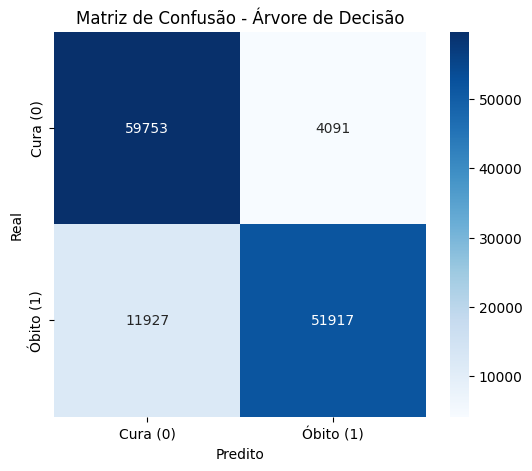

/tmp/ipykernel_313889/1903245301.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância', y='Variável', data=importancias, palette='viridis')


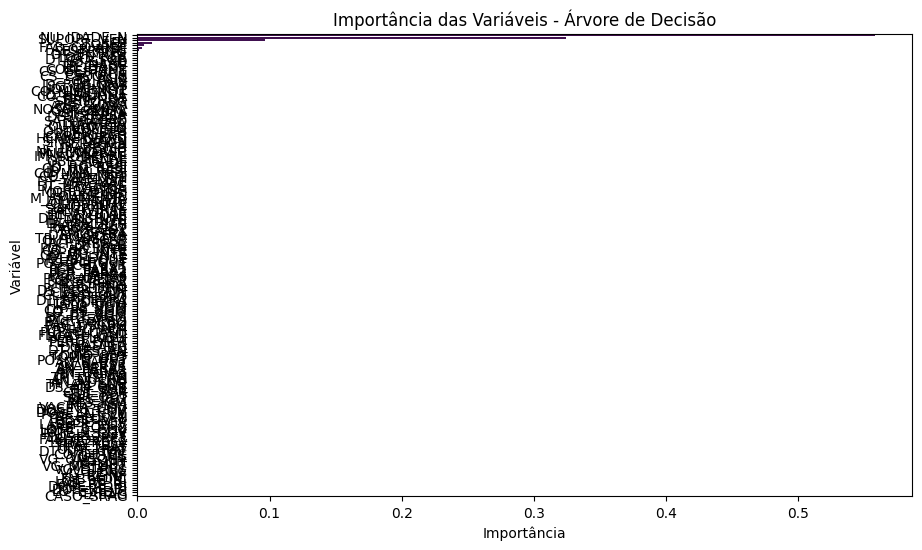


Importância das variáveis:
       Variável  Importância
11   NU_IDADE_N     0.558175
75   SUPORT_VEN     0.323857
72          UTI     0.096235
29        TOSSE     0.010841
155  FAB_COVREF     0.005354
..          ...          ...
181   DOSE_ADIC     0.000000
182   DOS_RE_BI     0.000000
183   LOTE_ADIC     0.000000
184       TABAG     0.000000
185   CASO_SRAG     0.000000

[186 rows x 2 columns]


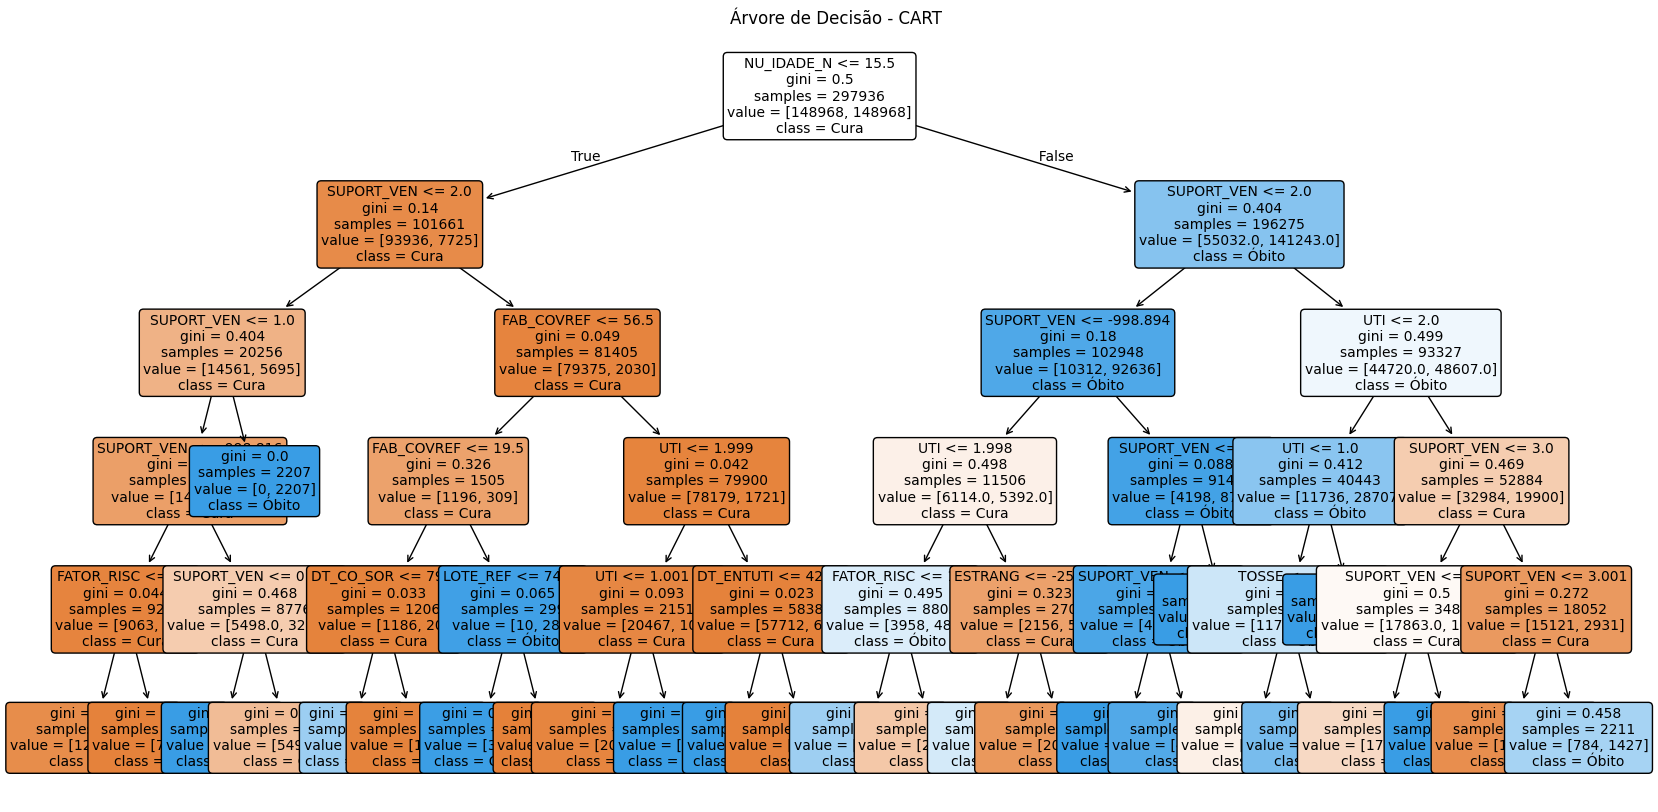


⏰ Tempo total de execução: 32.37 segundos


In [2]:
# 📌 Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

from imblearn.over_sampling import SMOTE

# ⏰ Cronômetro
start_time = time.time()

# 📌 1. Carregar os dados
df = pd.read_csv("./INFLUD24-03-02-2025.csv", sep=";", encoding="latin1", low_memory=False)

# 📌 2. Selecionar variável alvo e filtrar
df = df[df['EVOLUCAO'].isin([1, 2])].copy()
df['EVOLUCAO'] = df['EVOLUCAO'].map({1: 0, 2: 1})  # 0 = Cura, 1 = Óbito

# 📌 3. Selecionar colunas preditoras
# Remove 'EVOLUCAO' e colunas que não fazem sentido (ID's, datas, etc.)
colunas_remover = ['EVOLUCAO', 'DT_NOTIFIC', 'DT_INTERNA', 'DT_SIN_PRI', 'DT_EVOLUCA']  # adicione outras se necessário
variaveis = [col for col in df.columns if col not in colunas_remover]

X = df[variaveis].copy()
y = df['EVOLUCAO']

# 📌 4. Converter variáveis categóricas em numéricas
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = X[col].fillna('Desconhecido')
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    else:
        X[col] = pd.to_numeric(X[col], errors='coerce')

# 📌 5. Tratar valores ausentes
X = X.fillna(-999)  # ou outra estratégia

# 📌 6. Balanceamento
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

# 📌 7. Treinamento do modelo
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.3, random_state=42, stratify=y_res
)

clf = DecisionTreeClassifier(random_state=42, criterion='gini', max_depth=5)
clf.fit(X_train, y_train)

# 📌 8. Avaliação
y_pred = clf.predict(X_test)
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))

# 📌 9. Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cura (0)', 'Óbito (1)'],
            yticklabels=['Cura (0)', 'Óbito (1)'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Árvore de Decisão')
plt.show()

# 📌 10. Importância das variáveis
importancias = pd.DataFrame({
    'Variável': X.columns,
    'Importância': clf.feature_importances_
}).sort_values(by='Importância', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importância', y='Variável', data=importancias, palette='viridis')
plt.title('Importância das Variáveis - Árvore de Decisão')
plt.show()

print("\nImportância das variáveis:")
print(importancias)

# 📌 11. Árvore de Decisão
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=['Cura', 'Óbito'],
          filled=True, rounded=True, fontsize=10)
plt.title("Árvore de Decisão - CART")
plt.show()

# ⏰ Tempo total
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\n⏰ Tempo total de execução: {elapsed_time:.2f} segundos")



✅ Top variáveis mais importantes para prever a EVOLUCAO:

  Variável  Importância
NU_IDADE_N     0.558175
SUPORT_VEN     0.323857
       UTI     0.096235
     TOSSE     0.010841
FAB_COVREF     0.005354
FATOR_RISC     0.003949
   ESTRANG     0.000991
 DT_ENTUTI     0.000413
  LOTE_REF     0.000135
 DT_CO_SOR     0.000051
   CS_SEXO     0.000000
   DT_NASC     0.000000
  TP_IDADE     0.000000
 COD_IDADE     0.000000
CS_GESTANT     0.000000
   CS_RACA     0.000000
CS_ESCOL_N     0.000000
   ID_PAIS     0.000000
   CO_PAIS     0.000000
ID_REGIONA     0.000000


/tmp/ipykernel_313889/3066053185.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância', y='Variável', data=importancias_top, palette='viridis')


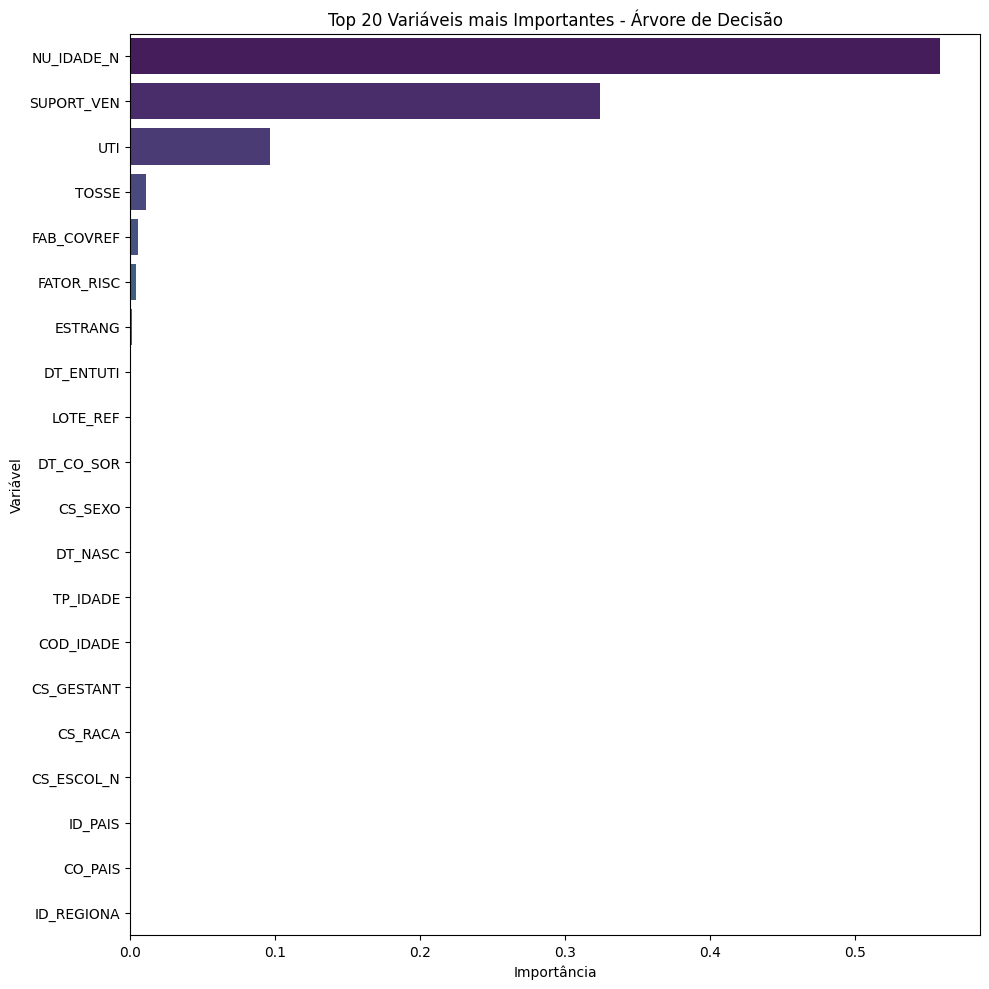

In [3]:
# 📌 Mostrar top N variáveis mais importantes
top_n = 20  # ✅ Altere para 10, 20, 30 conforme quiser

importancias = pd.DataFrame({
    'Variável': X.columns,
    'Importância': clf.feature_importances_
})

importancias = importancias.sort_values(by='Importância', ascending=False)

# Filtra apenas as mais importantes
importancias_top = importancias.head(top_n)

# 📌 Tabela bonita
print("\n✅ Top variáveis mais importantes para prever a EVOLUCAO:\n")
print(importancias_top.to_string(index=False))

# 📌 Gráfico horizontal das mais importantes
plt.figure(figsize=(10, 0.5 * top_n))  # Altura proporcional ao número de variáveis
sns.barplot(x='Importância', y='Variável', data=importancias_top, palette='viridis')
plt.title(f'Top {top_n} Variáveis mais Importantes - Árvore de Decisão')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()
